In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [2]:
from tensorflow.keras.utils import to_categorical # 분류분석시 원핫인코딩
from tensorflow.keras.models import Sequential # 모델생성
from tensorflow.keras.layers import Dense, Input
import numpy as np

# 머신러닝/딥러닝 : 데이터의 법칙성을 추출
- 다양한 분야에서 응용 : 글씨인식, 문장분류, 질병진단,... ※ ML/DL의 종류
- 지도학습(독립=입력변수와 종속=타겟=출력변수가 모두 주어졌을 경우) 회귀분석(타겟변수가 연속형) vs 분류분석(multi, binary)
- 비지도학습(입력변수만) 군집화
- 강화학습  


※ 지도학습에서의 ML, DL 프로그래밍 방식

1. 데이터 셋 확보(input=입력변수, target=종속변수) 원본 데이터 및 시뮬레이션을 통해 데이터 생성
2. 전처리 스케일 조정 훈련셋(학습셋), 검증셋, 시험셋(테스트셋) 학습 및 평가 가능한 포맷으로 변환
3. 모델 구성 Sequential 객체 생성뒤 필요한 층을 add()함수로 추가
4. 모델 학습과정 설정 compile()함수 이용. 손실함수, optimizer, metrics(평가지표)
5. 모델학습시키기 (ft. 학습과정 지켜보기) fit()함수 이용 - 훈련셋입력=독립변수, 훈련셋타겟=종속변수, 학습횟수, 검증셋
6. 모델 평가 시험셋(테스트셋)을 인자로 넣은 evaluate()함수 이용, 그래프
7. 모델 사용 predict() 이용. 입력데이터는 2차원 데이터
8. 모델 저장 save()함수이용해서 저장. 저장된 모델은 load_model()함수를 이용해서 불러올 수 있음

# 1. 데이터 셋 생성
# 2. 데이터 전처리

In [3]:
# 학습데이터 = 훈련데이터
x_train = np.array([1,2,3,4,5,6,7,8,9]*10)
y_train = np.array([2,4,6,8,10,12,14,16,18]*10)
# 검증데이터
x_val = np.array([1,2,3,4,5,6,7,8,9])
y_val = np.array([2,4,6,8,10,12,14,16,18])
# 테스트셋 = 시험데이터
x_test = np.array([1,2,3,4,5,6,7,8,9])
y_test = np.array([2,4,6,8,10,12,14,16,18])
x_train.shape, x_val.shape, x_test.shape, y_train.shape, y_val.shape, y_test.shape

((90,), (9,), (9,), (90,), (9,), (9,))

In [29]:
# 인코딩 종류
data = np.array(['a','b','c','d'])
print('원 데이터 :', data)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# le.fit(data)
# labeled_data = le.transform(data)
labeled_data = le.fit_transform(data)
print('라벨인코딩된 데이터 :', labeled_data)
one_hot_encoded_data = to_categorical(labeled_data)
print('원핫인코딩된 데이터 :', one_hot_encoded_data)

원 데이터 : ['a' 'b' 'c' 'd']
라벨인코딩된 데이터 : [0 1 2 3]
원핫인코딩된 데이터 : [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


In [5]:
# 인코딩의 종류
data = np.array(['서울','경기','인천','부산']) # 문자보다는 숫자를 더 인식한다...
print('원 데이터 :', data)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(data)
labeled_data = le.transform(data)
print('라벨인코딩된 데이터', labeled_data)

원 데이터 : ['서울' '경기' '인천' '부산']
라벨인코딩된 데이터 [2 0 3 1]


In [6]:
# 인코딩의 종류
data = np.array(['a','b','c','d']) 
print('원 데이터 :', data)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(data)
labeled_data = le.transform(data)
print('라벨인코딩된 데이터 :', labeled_data)
one_hot_encoded_data = to_categorical(labeled_data)
print('원핫인코딩된 데이터 :', one_hot_encoded_data) # 원핫인코딩이 라벨인코딩보다 더 사용이 많고 좋다.

원 데이터 : ['a' 'b' 'c' 'd']
라벨인코딩된 데이터 : [0 1 2 3]
원핫인코딩된 데이터 : [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


In [30]:
# 분류분석을 위기 위해, target을 원핫인코딩(라벨링 전환)
data = np.array([1,2,2,4,2])
print(data)
categorical_one_hot = to_categorical(data)
print('to_categorical을 이용한 원핫인코딩 :\n', categorical_one_hot)
import pandas as pd
get_dumies_one_hot = pd.get_dummies(data)
display('get_dumies를 이용한 원핫인코딩 :', get_dumies_one_hot)
print(type(categorical_one_hot))
print(type(get_dumies_one_hot))

[1 2 2 4 2]
to_categorical을 이용한 원핫인코딩 :
 [[0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0.]]


'get_dumies를 이용한 원핫인코딩 :'

,1,2,4
0,1,0,0
1,0,1,0
2,0,1,0
3,0,0,1
4,0,1,0


<class 'numpy.ndarray'>
<class 'pandas.core.frame.DataFrame'>


In [31]:
# 분류분석을 위한 target변수 라벨링 전환(=원핫인코딩)
Y_train = to_categorical(y_train, 19)
Y_val   = to_categorical(y_val)
Y_test = to_categorical(y_test)

In [32]:
print('훈련셋 구조:', x_train.shape, Y_train.shape) # 독립변수1개, 타겟변수 19
print('검증셋 구조:', x_val.shape, Y_val.shape)
print('테스트셋 구조:', x_test.shape, Y_test.shape)

훈련셋 구조: (90,) (90, 19)
검증셋 구조: (9,) (9, 19)
테스트셋 구조: (9,) (9, 19)


# 3. 모델 구성하기

In [33]:
model = Sequential()
model.add(Input(shape=(1,))) # 입력층
model.add(Dense(units=38, activation='sigmoid')) # units출력수, 활성화함수:relu, tanh
model.add(Dense(units=64, activation='elu'))
model.add(Dense(units=32, activation='elu'))
model.add(Dense(units=19, activation='softmax'))
# softmax : 모든 출력결과의 합이 1. 분류분석 마지막 layer(출력층)에서 activation으로
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 38)                76        
                                                                 
 dense_5 (Dense)             (None, 64)                2496      
                                                                 
 dense_6 (Dense)             (None, 32)                2080      
                                                                 
 dense_7 (Dense)             (None, 19)                627       
                                                                 
Total params: 5,279
Trainable params: 5,279
Non-trainable params: 0
_________________________________________________________________


# 4. 모델 학습과정 설정

In [34]:
model.compile(loss="categorical_crossentropy", # 분류분석에서의 손실함수(원핫인코딩有)
             optimizer='sgd',
             metrics=['accuracy']) # 평가지표 : accuracy 

# 5. 모델 학습시키기

In [35]:
hist = model.fit(x_train, Y_train, 
            epochs=300, 
            batch_size=10,
            verbose=2, # 학습결과 출력 옵션 0:출력없음. 1:기본값, 2:에포크별로그상세출력
            validation_data=(x_val, Y_val)
            )

Epoch 1/300
9/9 - 1s - loss: 2.9239 - accuracy: 0.1111 - val_loss: 2.8372 - val_accuracy: 0.1111 - 597ms/epoch - 66ms/step
Epoch 2/300
9/9 - 0s - loss: 2.8087 - accuracy: 0.1111 - val_loss: 2.7443 - val_accuracy: 0.1111 - 45ms/epoch - 5ms/step
Epoch 3/300
9/9 - 0s - loss: 2.7210 - accuracy: 0.1111 - val_loss: 2.6717 - val_accuracy: 0.1111 - 43ms/epoch - 5ms/step
Epoch 4/300
9/9 - 0s - loss: 2.6600 - accuracy: 0.1111 - val_loss: 2.6133 - val_accuracy: 0.1111 - 47ms/epoch - 5ms/step
Epoch 5/300
9/9 - 0s - loss: 2.6043 - accuracy: 0.1000 - val_loss: 2.5641 - val_accuracy: 0.1111 - 44ms/epoch - 5ms/step
Epoch 6/300
9/9 - 0s - loss: 2.5607 - accuracy: 0.0778 - val_loss: 2.5203 - val_accuracy: 0.1111 - 48ms/epoch - 5ms/step
Epoch 7/300
9/9 - 0s - loss: 2.5132 - accuracy: 0.0444 - val_loss: 2.4795 - val_accuracy: 0.1111 - 41ms/epoch - 5ms/step
Epoch 8/300
9/9 - 0s - loss: 2.4774 - accuracy: 0.0222 - val_loss: 2.4422 - val_accuracy: 0.0000e+00 - 44ms/epoch - 5ms/step
Epoch 9/300
9/9 - 0s - los

Epoch 69/300
9/9 - 0s - loss: 1.6424 - accuracy: 0.3333 - val_loss: 1.6112 - val_accuracy: 0.3333 - 56ms/epoch - 6ms/step
Epoch 70/300
9/9 - 0s - loss: 1.6286 - accuracy: 0.4000 - val_loss: 1.5988 - val_accuracy: 0.4444 - 64ms/epoch - 7ms/step
Epoch 71/300
9/9 - 0s - loss: 1.6216 - accuracy: 0.4111 - val_loss: 1.5876 - val_accuracy: 0.3333 - 49ms/epoch - 5ms/step
Epoch 72/300
9/9 - 0s - loss: 1.6112 - accuracy: 0.3889 - val_loss: 1.5762 - val_accuracy: 0.4444 - 43ms/epoch - 5ms/step
Epoch 73/300
9/9 - 0s - loss: 1.5976 - accuracy: 0.3778 - val_loss: 1.5650 - val_accuracy: 0.4444 - 49ms/epoch - 5ms/step
Epoch 74/300
9/9 - 0s - loss: 1.5897 - accuracy: 0.4444 - val_loss: 1.5533 - val_accuracy: 0.4444 - 48ms/epoch - 5ms/step
Epoch 75/300
9/9 - 0s - loss: 1.5719 - accuracy: 0.3667 - val_loss: 1.5431 - val_accuracy: 0.5556 - 45ms/epoch - 5ms/step
Epoch 76/300
9/9 - 0s - loss: 1.5721 - accuracy: 0.3667 - val_loss: 1.5323 - val_accuracy: 0.4444 - 46ms/epoch - 5ms/step
Epoch 77/300
9/9 - 0s - 

Epoch 136/300
9/9 - 0s - loss: 1.0948 - accuracy: 0.7111 - val_loss: 1.0701 - val_accuracy: 0.8889 - 57ms/epoch - 6ms/step
Epoch 137/300
9/9 - 0s - loss: 1.0907 - accuracy: 0.8111 - val_loss: 1.0639 - val_accuracy: 0.8889 - 57ms/epoch - 6ms/step
Epoch 138/300
9/9 - 0s - loss: 1.0881 - accuracy: 0.7444 - val_loss: 1.0586 - val_accuracy: 1.0000 - 57ms/epoch - 6ms/step
Epoch 139/300
9/9 - 0s - loss: 1.0799 - accuracy: 0.8222 - val_loss: 1.0532 - val_accuracy: 0.8889 - 54ms/epoch - 6ms/step
Epoch 140/300
9/9 - 0s - loss: 1.0748 - accuracy: 0.8111 - val_loss: 1.0465 - val_accuracy: 0.8889 - 52ms/epoch - 6ms/step
Epoch 141/300
9/9 - 0s - loss: 1.0614 - accuracy: 0.8556 - val_loss: 1.0497 - val_accuracy: 0.7778 - 48ms/epoch - 5ms/step
Epoch 142/300
9/9 - 0s - loss: 1.0595 - accuracy: 0.7111 - val_loss: 1.0420 - val_accuracy: 0.7778 - 49ms/epoch - 5ms/step
Epoch 143/300
9/9 - 0s - loss: 1.0691 - accuracy: 0.7000 - val_loss: 1.0300 - val_accuracy: 0.8889 - 53ms/epoch - 6ms/step
Epoch 144/300
9/

Epoch 203/300
9/9 - 0s - loss: 0.7934 - accuracy: 0.8222 - val_loss: 0.7603 - val_accuracy: 0.8889 - 44ms/epoch - 5ms/step
Epoch 204/300
9/9 - 0s - loss: 0.7911 - accuracy: 0.8444 - val_loss: 0.7616 - val_accuracy: 0.8889 - 48ms/epoch - 5ms/step
Epoch 205/300
9/9 - 0s - loss: 0.7783 - accuracy: 0.9333 - val_loss: 0.7575 - val_accuracy: 1.0000 - 46ms/epoch - 5ms/step
Epoch 206/300
9/9 - 0s - loss: 0.7850 - accuracy: 0.8778 - val_loss: 0.7610 - val_accuracy: 1.0000 - 45ms/epoch - 5ms/step
Epoch 207/300
9/9 - 0s - loss: 0.7699 - accuracy: 0.9000 - val_loss: 0.7546 - val_accuracy: 0.8889 - 46ms/epoch - 5ms/step
Epoch 208/300
9/9 - 0s - loss: 0.7917 - accuracy: 0.8556 - val_loss: 0.7468 - val_accuracy: 0.8889 - 53ms/epoch - 6ms/step
Epoch 209/300
9/9 - 0s - loss: 0.7798 - accuracy: 0.7667 - val_loss: 0.7367 - val_accuracy: 1.0000 - 42ms/epoch - 5ms/step
Epoch 210/300
9/9 - 0s - loss: 0.7641 - accuracy: 0.9000 - val_loss: 0.7407 - val_accuracy: 0.7778 - 47ms/epoch - 5ms/step
Epoch 211/300
9/

Epoch 270/300
9/9 - 0s - loss: 0.5638 - accuracy: 0.9556 - val_loss: 0.5374 - val_accuracy: 1.0000 - 48ms/epoch - 5ms/step
Epoch 271/300
9/9 - 0s - loss: 0.5750 - accuracy: 0.9000 - val_loss: 0.5361 - val_accuracy: 1.0000 - 48ms/epoch - 5ms/step
Epoch 272/300
9/9 - 0s - loss: 0.6062 - accuracy: 0.8556 - val_loss: 0.5331 - val_accuracy: 1.0000 - 45ms/epoch - 5ms/step
Epoch 273/300
9/9 - 0s - loss: 0.5769 - accuracy: 0.9000 - val_loss: 0.5684 - val_accuracy: 0.7778 - 46ms/epoch - 5ms/step
Epoch 274/300
9/9 - 0s - loss: 0.5484 - accuracy: 0.9444 - val_loss: 0.5252 - val_accuracy: 1.0000 - 44ms/epoch - 5ms/step
Epoch 275/300
9/9 - 0s - loss: 0.5516 - accuracy: 0.8778 - val_loss: 0.5519 - val_accuracy: 0.8889 - 42ms/epoch - 5ms/step
Epoch 276/300
9/9 - 0s - loss: 0.5601 - accuracy: 0.8889 - val_loss: 0.5235 - val_accuracy: 1.0000 - 56ms/epoch - 6ms/step
Epoch 277/300
9/9 - 0s - loss: 0.5685 - accuracy: 0.9111 - val_loss: 0.5394 - val_accuracy: 0.8889 - 51ms/epoch - 6ms/step
Epoch 278/300
9/

# 6. 모델 평가하기(모델학습과정 살펴보고, evalute)

In [36]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

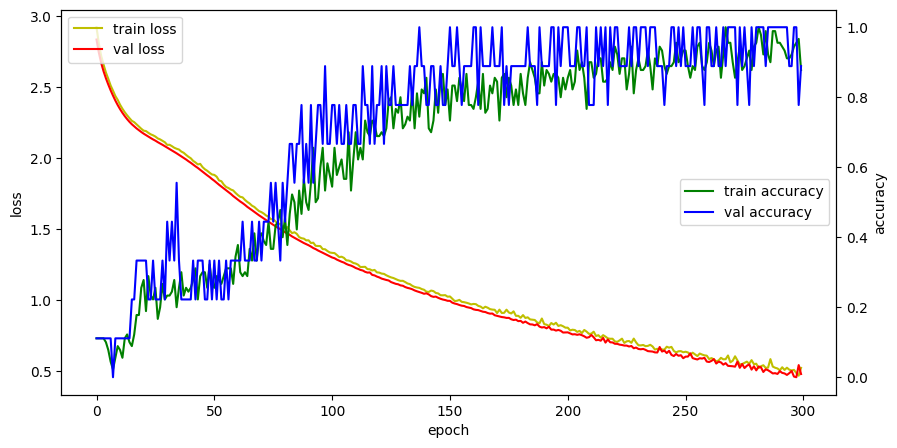

In [37]:
# 모델 학습과정 시각화
import matplotlib.pyplot as plt
fig, loss_ax = plt.subplots(figsize=(10,5))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')

acc_ax = loss_ax.twinx() # loss_ax와 x축을 공유하는 acc_ax생성
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='upper left')
acc_ax.legend(loc='center right')
plt.show()

In [39]:
# 모델 평가
score = model.evaluate(x_test, Y_test, batch_size=1)

9/9 [==============================] - 0s 2ms/step - loss: 0.4812 - accuracy: 0.8889


In [40]:
score # loss, accuracy

[0.48118290305137634, 0.8888888955116272]

In [41]:
print('평가된 loss :', score[0])
print('평가된 accuracy :', score[1]*100, '%')

평가된 loss : 0.48118290305137634
평가된 accuracy : 88.88888955116272 %


# 7. 모델 사용하기 

In [42]:
H = model.predict(np.array([[2]]))
H

1/1 [==============================] - 0s 65ms/step


array([[9.73026930e-14, 2.06777607e-12, 7.53046796e-02, 1.30141395e-12,
        8.22258472e-01, 3.24611215e-13, 1.00644134e-01, 1.15177880e-14,
        1.78784051e-03, 9.03816139e-14, 4.90357206e-06, 6.26331864e-15,
        1.62303071e-09, 5.07286762e-15, 1.04749156e-13, 8.31827224e-16,
        1.06264388e-18, 8.15909909e-11, 3.74091954e-26]], dtype=float32)

In [43]:
# 분류분석의 예측은 predict()후 argmax()
model.predict(np.array([[2]])).argmax() 

1/1 [==============================] - 0s 30ms/step


4

In [44]:
# 4를 몇%확률로 예측했는지 
H[0, H.argmax()]*100

82.2258472442627

# 7. 모델 저장하기

In [45]:
# model.save('model/02_deep.h5')
from tensorflow.keras.models import save_model
save_model(model, 'model/02_deep.h5')

## 저장된 모델 사용하기

In [48]:
from tensorflow.keras.models import load_model
model2 = load_model('model/02_deep.h5')

In [49]:
model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 38)                76        
                                                                 
 dense_5 (Dense)             (None, 64)                2496      
                                                                 
 dense_6 (Dense)             (None, 32)                2080      
                                                                 
 dense_7 (Dense)             (None, 19)                627       
                                                                 
Total params: 5,279
Trainable params: 5,279
Non-trainable params: 0
_________________________________________________________________


In [50]:
data = np.array([[2], 
                 [3]])
predictions = model2.predict(data)
predictions.argmax(axis=-1)

1/1 [==============================] - 0s 69ms/step


array([4, 6], dtype=int64)

In [51]:
def predict_classes(model, data):
    predictions = model.predict(data)
    return predictions.argmax(axis=-1)

In [54]:
import numpy as np
input_data = int(input('어떤 데이터를 예측할까요?'))
data = np.array([[input_data]])
print('예측된 분류는', predict_classes(model2, data))

어떤 데이터를 예측할까요?3
1/1 [==============================] - 0s 34ms/step
예측된 분류는 [6]
